# Analyse du dataset GUIDE — Microsoft Security Incident Prediction

**Source :** https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction

**Objectif :** Classifier les incidents de cybersécurité en 3 classes : `TruePositive (TP)`, `BenignPositive (BP)`, `FalsePositive (FP)`

---
### Plan du notebook
1. Chargement & échantillonnage
2. Sélection des colonnes
3. Traitement des valeurs manquantes
4. Feature engineering
5. Analyse exploratoire (EDA)
6. Encodage & préparation pour la modélisation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

---
## 1. Chargement et échantillonnage stratifié

Le fichier original (~2.43 Go) est lu par blocs pour éviter les problèmes de mémoire.
Un échantillon de 1 % est extrait en conservant la distribution de la variable cible `IncidentGrade`.

**Correction apportée :** le paramètre par défaut `cible` pointe maintenant vers `'IncidentGrade'` (était `'y'` — trompeur).

In [2]:
def echantillonner_stratifie(chemin, frac=0.01, cible='IncidentGrade', chemin_sortie='../echantillon.csv'):
    """
    Lit un CSV volumineux par blocs et produit un échantillon stratifié.

    Paramètres
    ----------
    chemin        : chemin vers le CSV source
    frac          : fraction à échantillonner par classe (défaut 1 %)
    cible         : colonne de stratification (défaut 'IncidentGrade')
    chemin_sortie : où sauvegarder l'échantillon
    """
    sample_list = []

    for chunk in pd.read_csv(chemin, chunksize=10_000):
        chunk = chunk.dropna(subset=[cible])
        sample = (
            chunk
            .groupby(cible, group_keys=False)
            .apply(lambda x: x.sample(frac=frac, random_state=2026))
        )
        sample_list.append(sample)

    df_sample = pd.concat(sample_list).reset_index(drop=True)
    df_sample.to_csv(chemin_sortie, index=False)
    print(f'Échantillon sauvegardé : {df_sample.shape[0]:,} lignes, {df_sample.shape[1]} colonnes')
    return df_sample

# Décommenter pour régénérer l'échantillon :
# echantillonner_stratifie('../GUIDE_Train.csv', frac=0.01)

In [3]:
echantillon = pd.read_csv('../echantillon.csv', low_memory=False)
print(f'Dimensions brutes : {echantillon.shape[0]:,} lignes x {echantillon.shape[1]} colonnes')
print(echantillon.columns)
echantillon.head()

Dimensions brutes : 94,638 lignes x 45 colonnes
Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,884763264609,21,111280,263403,2024-06-09T11:29:01.000Z,3,4,SuspiciousActivity,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
1,515396079824,36,30247,97984,2024-06-05T09:54:14.000Z,10,8,InitialAccess,T1566.001,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630
2,1511828491965,12,2420,1652,2024-05-23T01:55:44.000Z,16,186,Impact,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
3,223338304201,38,289307,693576,2024-06-13T12:58:35.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,0,0,NaN,Suspicious,Suspicious,242,1445,10630
4,335007450734,26,60218,421825,2024-06-10T07:23:12.000Z,497,539,Discovery,T1069.001;T1069.002,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


---
## 2. Sélection des colonnes

On conserve les colonnes sémantiquement utiles et on écarte :
- Les identifiants purs (aucune valeur prédictive)
- Les colonnes à >70 % de valeurs manquantes après vérification

In [4]:
COLONNES_UTILES = [
    'Timestamp',
    'Category',
    'MitreTechniques',
    'IncidentGrade',      # variable cible
    'EntityType',
    'EvidenceRole',
    'RegistryValueData',  # sera binarisée
    'OSFamily',
    'OSVersion',
    'SuspicionLevel',
    'LastVerdict',
    'CountryCode',
    'State',
    'City'
]

df = echantillon[COLONNES_UTILES].copy()
print(f'Colonnes conservées : {df.shape[1]}')
df.info()

Colonnes conservées : 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94638 entries, 0 to 94637
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Timestamp          94638 non-null  object
 1   Category           94638 non-null  object
 2   MitreTechniques    40574 non-null  object
 3   IncidentGrade      94638 non-null  object
 4   EntityType         94638 non-null  object
 5   EvidenceRole       94638 non-null  object
 6   RegistryValueData  94638 non-null  int64 
 7   OSFamily           94638 non-null  int64 
 8   OSVersion          94638 non-null  int64 
 9   SuspicionLevel     14371 non-null  object
 10  LastVerdict        22342 non-null  object
 11  CountryCode        94638 non-null  int64 
 12  State              94638 non-null  int64 
 13  City               94638 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 10.1+ MB


### Audit des NaN

In [5]:
nan_df = pd.DataFrame({
    'Colonne': df.columns,
    'NaN': df.isna().sum().values,
    'Pct_NaN': (df.isna().mean() * 100).round(2).values
}).sort_values('Pct_NaN', ascending=False)

print(nan_df.to_string(index=False))

          Colonne   NaN  Pct_NaN
   SuspicionLevel 80267    84.81
      LastVerdict 72296    76.39
  MitreTechniques 54064    57.13
        Timestamp     0     0.00
         Category     0     0.00
    IncidentGrade     0     0.00
       EntityType     0     0.00
     EvidenceRole     0     0.00
RegistryValueData     0     0.00
         OSFamily     0     0.00
        OSVersion     0     0.00
      CountryCode     0     0.00
            State     0     0.00
             City     0     0.00


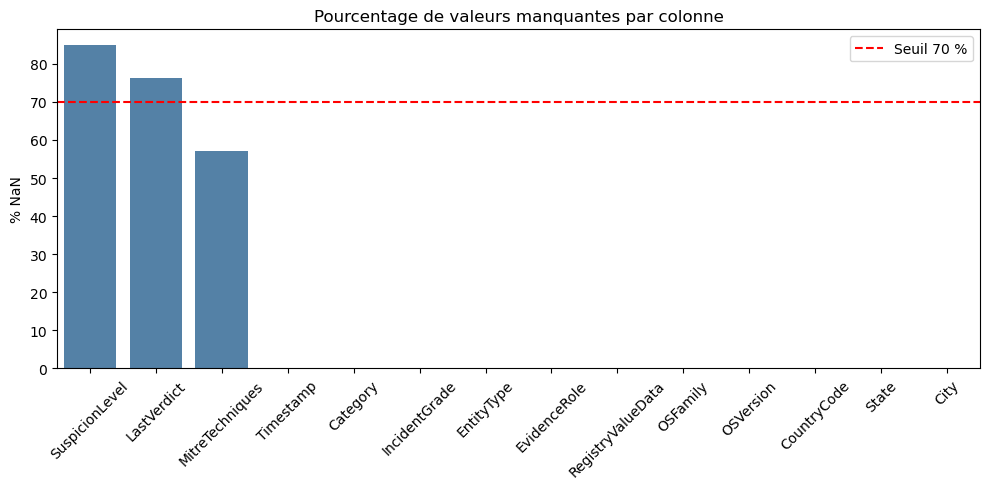

In [6]:
# Visualisation des NaN
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=nan_df, x='Colonne', y='Pct_NaN', ax=ax, color='steelblue')
ax.axhline(70, color='red', linestyle='--', label='Seuil 70 %')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.set_xlabel('')
ax.set_ylabel('% NaN')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Traitement des valeurs manquantes
| Colonne | Stratégie | Justification |
|---|---|---|
| `RegistryValueData` | Binariser --> `HasRegistryData` (0/1) | Haute cardinalité, la présence est informative |
| `MitreTechniques` | Remplir par `'Unknown'` | Absence = technique non identifiée |
| `SuspicionLevel` | Remplir par `'None'` | Absence = non évalué / non suspect |
| `LastVerdict` | Remplir par `'Unknown'` | Absence = verdict en attente |
| `OSVersion` | Remplir par `'Unknown'` | Info manquante fréquente |
| `CountryCode`, `State`, `City` | Remplir par `'Unknown'` | Données géo incomplètes |
| Lignes sans `IncidentGrade` | Supprimer | Cible indispensable |



In [7]:
# Remplissage des autres colonnes
fill_unknown = ['MitreTechniques', 'LastVerdict', 'OSVersion']
df[fill_unknown] = df[fill_unknown].fillna('Unknown')

df['SuspicionLevel'] = df['SuspicionLevel'].fillna('None')
df['OSFamily'] = df['OSFamily'].fillna('Unknown')

# Vérification
assert df.isna().sum().sum() == 0, 'Il reste des NaN !'
print(f' Aucune valeur manquante. Dimensions : {df.shape}')

 Aucune valeur manquante. Dimensions : (94638, 14)


### Simplification de `MitreTechniques` (haute cardinalité)

On extrait la **tactique principale** (premier identifiant T-xxxx) et on regroupe les valeurs rares en `'Other'`.

In [8]:
def extraire_technique_principale(val):
    """Extrait le premier identifiant T-xxxx d'une chaîne MITRE."""
    if pd.isna(val) or val == 'Unknown':
        return 'Unknown'
    match = re.search(r'T\d{4}(?:\.\d{3})?', str(val))
    return match.group(0) if match else 'Other'

df['MitreTechnique_Main'] = df['MitreTechniques'].apply(extraire_technique_principale)

# Garder les top 15 techniques + regrouper le reste en 'Other'
TOP_N = 15
top_techniques = df['MitreTechnique_Main'].value_counts().head(TOP_N).index
df['MitreTechnique_Main'] = df['MitreTechnique_Main'].where(
    df['MitreTechnique_Main'].isin(top_techniques), other='Other'
)

df = df.drop(columns=['MitreTechniques'])
print(f'Techniques distinctes après simplification : {df["MitreTechnique_Main"].nunique()}')
print(df['MitreTechnique_Main'].value_counts().head(10))

Techniques distinctes après simplification : 16
MitreTechnique_Main
Unknown      54064
T1078        14225
T1566.002     8130
T1566         6630
Other         3178
T1110         1799
T1133         1503
T1566.001     1390
T1046          763
T1087          655
Name: count, dtype: int64


### Réduction de cardinalité des autres colonnes géographiques

In [9]:
def reduire_cardinalite(series, top_n=20, fill='Other'):
    """Remplace les valeurs hors top_n par fill."""
    top_vals = series.value_counts().head(top_n).index
    return series.where(series.isin(top_vals), other=fill)

df['City']        = reduire_cardinalite(df['City'], top_n=20)
df['State']       = reduire_cardinalite(df['State'], top_n=20)
df['CountryCode'] = reduire_cardinalite(df['CountryCode'], top_n=30)
df['OSVersion']   = reduire_cardinalite(df['OSVersion'], top_n=15)

print('Cardinalités après réduction :')
for col in ['City','State','CountryCode','OSVersion']:
    print(f'  {col} : {df[col].nunique()} valeurs distinctes')

Cardinalités après réduction :
  City : 21 valeurs distinctes
  State : 21 valeurs distinctes
  CountryCode : 31 valeurs distinctes
  OSVersion : 16 valeurs distinctes


---
## 5. Analyse exploratoire  (EDA)

### 5.1   Distribution de la variable cible


C:\Users\fotsi\AppData\Local\Temp\ipykernel_33060\1315903392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=grade_counts.index, y=grade_counts.values, ax=axes[0], palette='Set2')


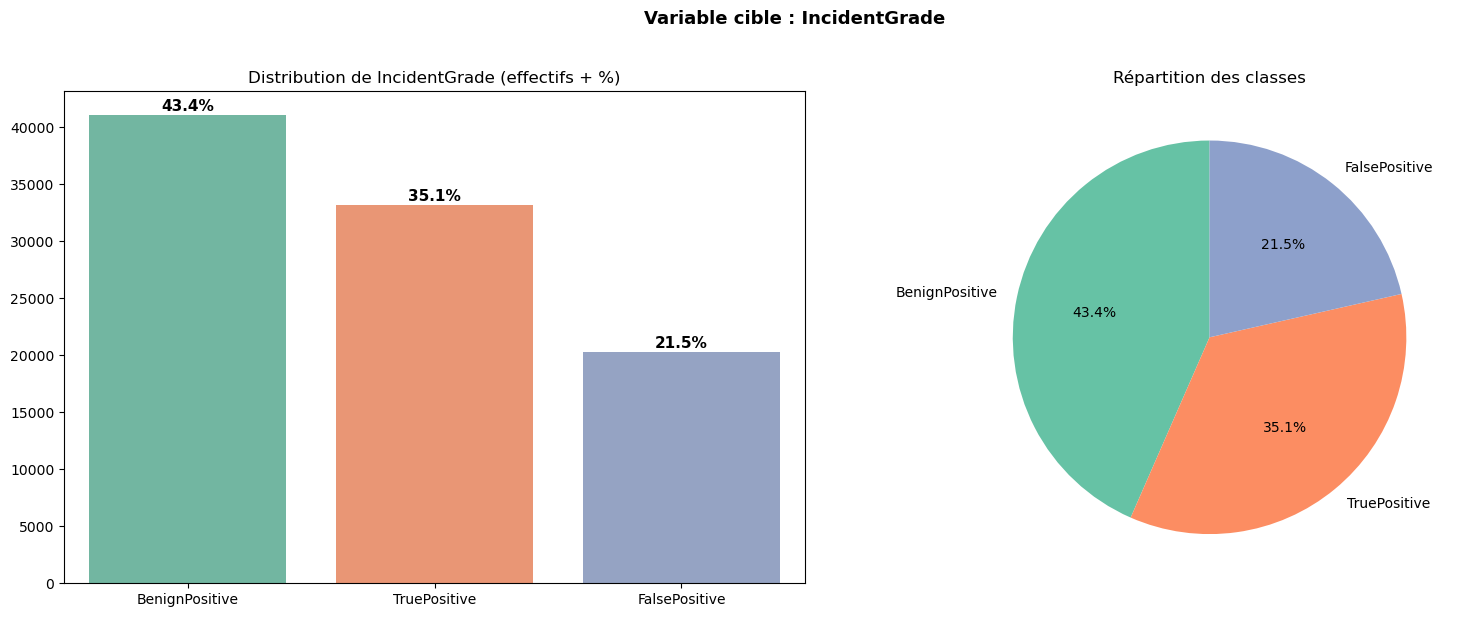

In [10]:
grade_counts = df['IncidentGrade'].value_counts()
grade_pct    = df['IncidentGrade'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# histogramme
bars = sns.barplot(x=grade_counts.index, y=grade_counts.values, ax=axes[0], palette='Set2')
for bar, pct in zip(bars.patches, grade_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution de IncidentGrade (effectifs + %)', fontsize=12)
axes[0].set_xlabel('')

# diagramme circulaire
axes[1].pie(grade_counts.values, labels=grade_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Répartition des classes', fontsize=12)

plt.suptitle('Variable cible : IncidentGrade', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Analyse bivariée — Features catégorielles vs IncidentGrade

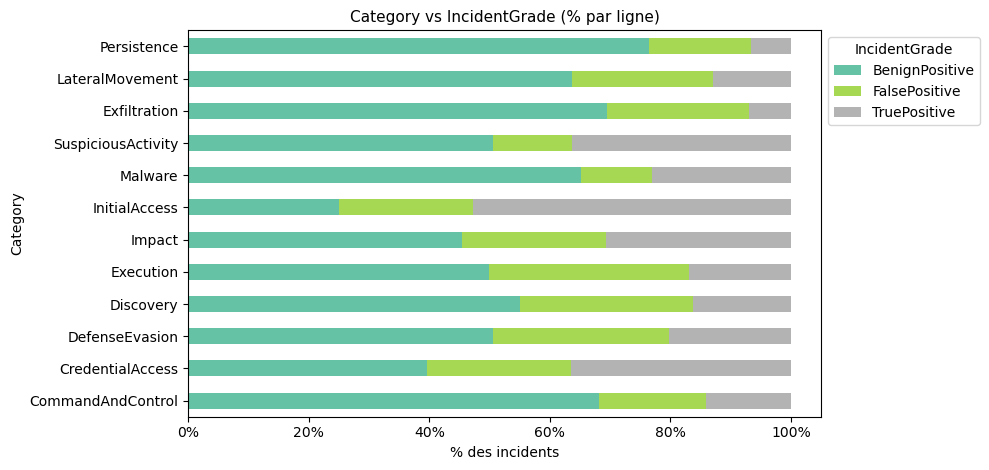

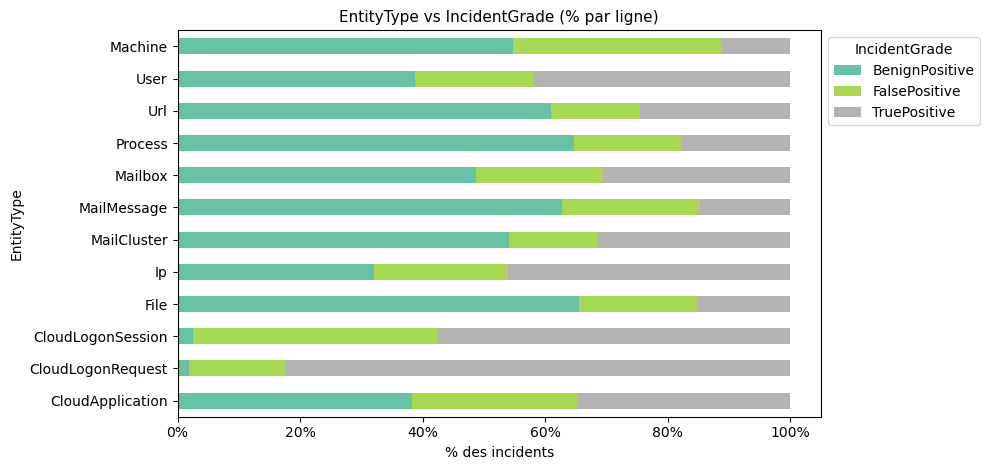

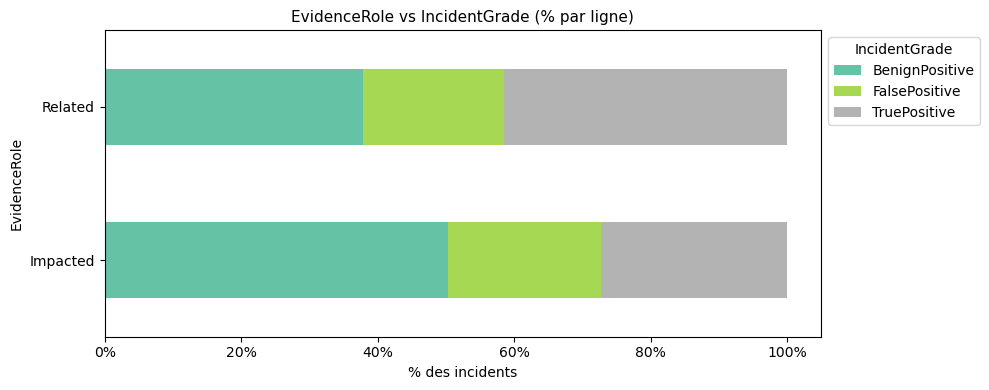

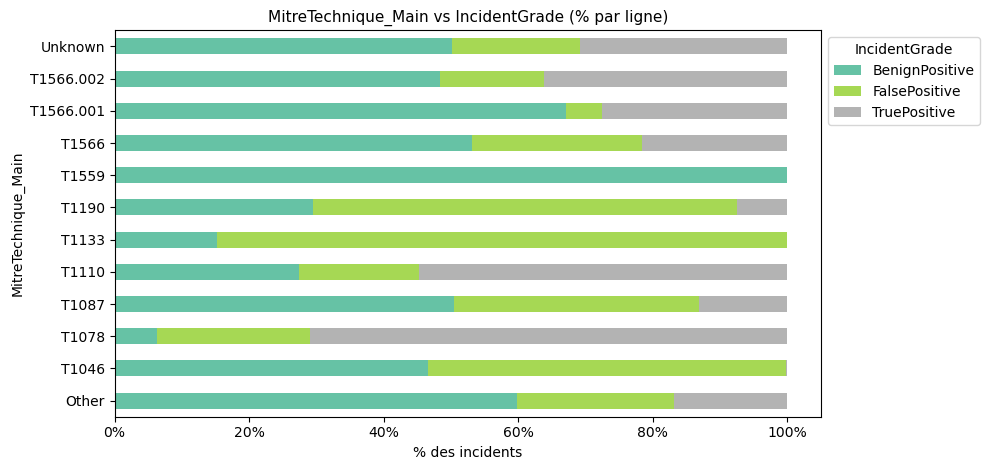

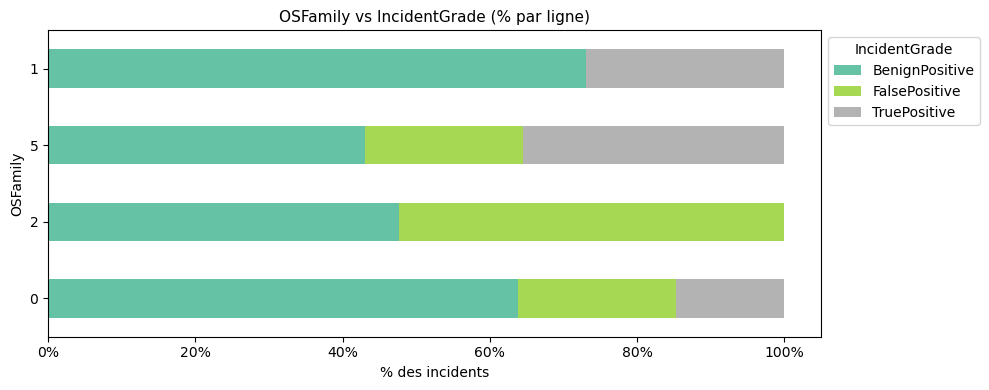

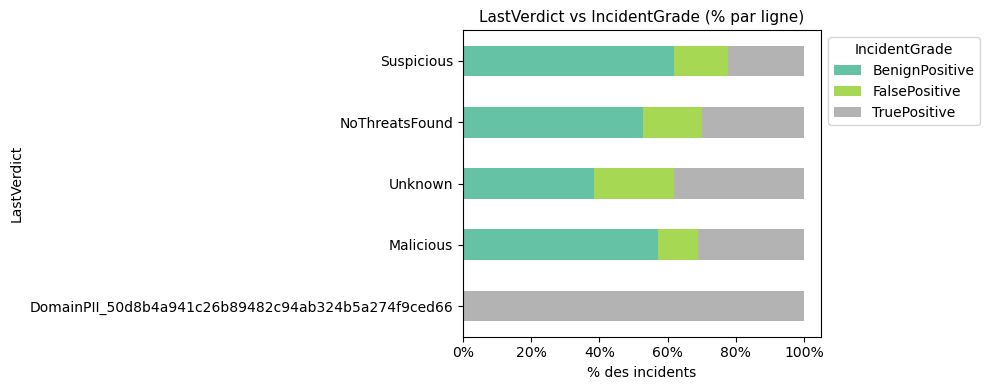

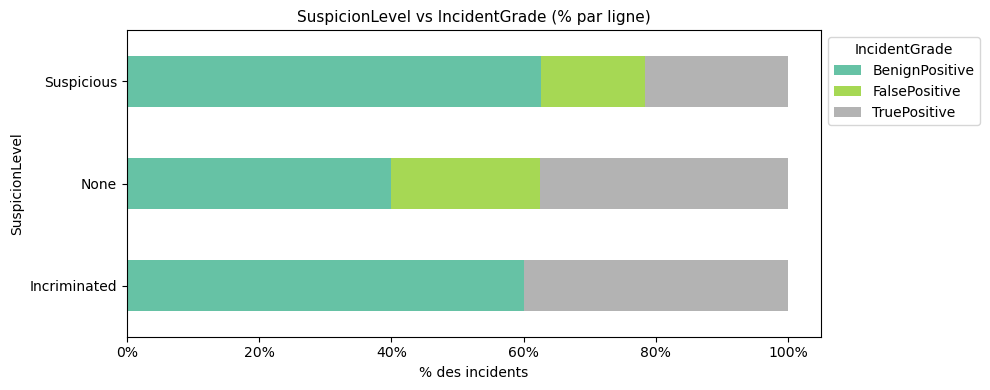

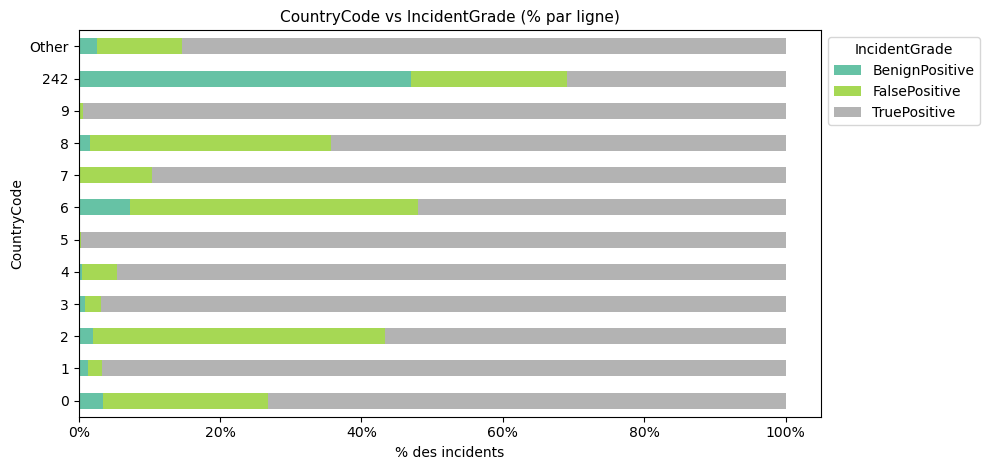

In [11]:
def plot_feature_vs_target(df, feature, target='IncidentGrade', top_n=12):
    """Barplot 100% empilé : distribution du target par modalité de feature."""
    top_vals = df[feature].value_counts().head(top_n).index
    sub = df[df[feature].isin(top_vals)]
    
    ct = pd.crosstab(sub[feature], sub[target], normalize='index') * 100
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

    ax = ct.plot(kind='barh', stacked=True, colormap='Set2', figsize=(10, max(4, len(ct)*0.4)))
    ax.set_title(f'{feature} vs {target} (% par ligne)', fontsize=11)
    ax.set_xlabel('% des incidents')
    ax.legend(title=target, bbox_to_anchor=(1,1))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()

for feat in ['Category', 'EntityType', 'EvidenceRole', 'MitreTechnique_Main',
             'OSFamily', 'LastVerdict', 'SuspicionLevel', 'CountryCode']:
    plot_feature_vs_target(df, feat)

## 4. Feature engineering

###  Analyse temporelle

Features temporelles créées : ['Hour', 'DayOfWeek', 'DayOfMonth', 'Month', 'IsWeekend', 'IsBusinessHour']


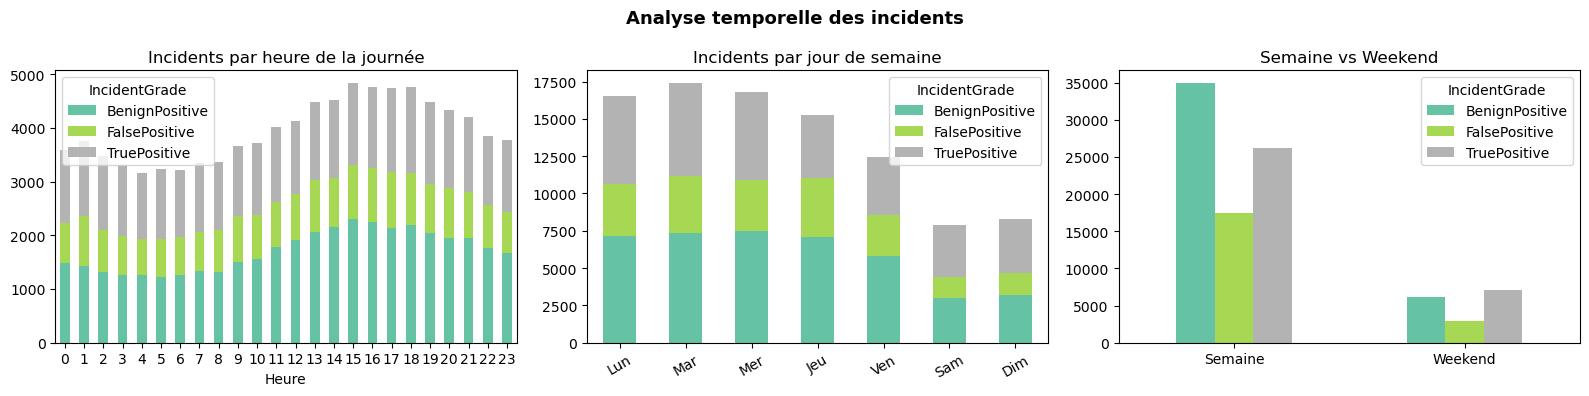

In [12]:
df_original = df.copy() # on sauvegarde une version pour pouvoir revenir en arriere après les calculs
df = df.copy()

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Hour']       = df['Timestamp'].dt.hour
df['DayOfWeek']  = df['Timestamp'].dt.dayofweek   # 0=lundi … 6=dimanche
df['DayOfMonth'] = df['Timestamp'].dt.day
df['Month']      = df['Timestamp'].dt.month
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['IsBusinessHour'] = df['Hour'].between(8, 18).astype(int)

#df = df.drop(columns=['Timestamp'])
print('Features temporelles créées :', ['Hour','DayOfWeek','DayOfMonth','Month','IsWeekend','IsBusinessHour'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Incidents par heure
hour_grade = df.groupby(['Hour','IncidentGrade']).size().unstack(fill_value=0)
hour_grade.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Incidents par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].tick_params(axis='x', rotation=0)

# Incidents par jour de semaine
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
dow_grade = df.groupby(['DayOfWeek','IncidentGrade']).size().unstack(fill_value=0)
dow_grade.index = [jours[i] for i in dow_grade.index]
dow_grade.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Incidents par jour de semaine')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Weekend vs semaine
we_grade = df.groupby(['IsWeekend','IncidentGrade']).size().unstack(fill_value=0)
we_grade.index = ['Semaine','Weekend']
we_grade.plot(kind='bar', stacked=False, ax=axes[2], colormap='Set2')
axes[2].set_title('Semaine vs Weekend')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Analyse temporelle des incidents', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

On observe un accroissement des activités pendant les heures ouvrables, en semaine. 
Aussi la répartition de la cible suit la même tendance peu importe le moment de la semaine ou de la journée.

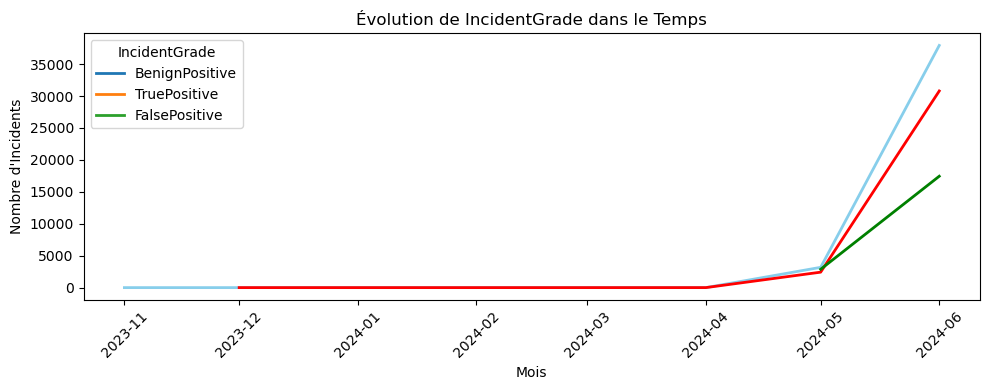

In [13]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Timestamp'] = df['Timestamp'].dt.tz_localize(None)
df['Month'] = df['Timestamp'].dt.to_period('M').dt.to_timestamp()
df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
df.drop('Timestamp', axis=1, errors='ignore', inplace=True)

incident_grade_monthly = (
    df.groupby(['Month', 'IncidentGrade'],observed=False)
       .size()
       .reset_index(name='Count')
)
# Graphique
plt.figure(figsize=(10, 4))

sns.lineplot(
    data=incident_grade_monthly,
    x='Month',
    y='Count',
    hue='IncidentGrade',
    linewidth=2
)


plt.title("Évolution de IncidentGrade dans le Temps")
plt.xlabel("Mois")
plt.ylabel("Nombre d'Incidents")

# Couleurs personnalisées
palette = {
    "BenignPositive": "skyblue",
    "TruePositive": "red",
    "FalsePositive": "green"
}
for line, grade in zip(plt.gca().lines, incident_grade_monthly['IncidentGrade'].unique()):
    line.set_color(palette.get(grade, "black"))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

interpretation : On remarque que les déclarations d’incidents sont stables durant l’hivers. et le système ne capture que les transactions frauduleuse.

C’est en mai et Juin que se dégagent la majorité des signalements. Possible lien avec tous les mouvements qui se déroulent durant l’été ? c’est une question qu’il faudra explorer.

Faisons un zoom sur les fluxtuations pendant le mois de mai

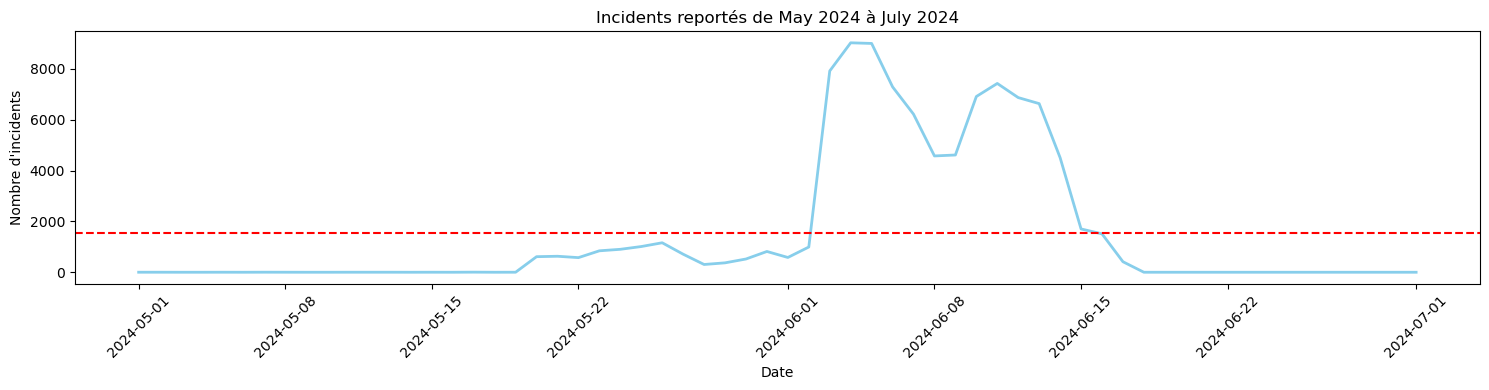

In [14]:
date_debut = pd.to_datetime("2024-05-01").date()
date_fin    = pd.to_datetime("2024-07-01").date()

donnees_filtrees  = df[(df['Date'] >= date_debut) & (df['Date'] <= date_fin )].copy()

toute_date  = pd.date_range(start=date_debut, end=date_fin ).date

decompte_journalier  = (
    donnees_filtrees .groupby('Date')
                 .size()
                 .reindex(toute_date , fill_value=0)
)

df_par_jour  = decompte_journalier .reset_index().rename(columns={'index': 'Date', 0:'Count'})

plt.figure(figsize=(15,4))
sns.lineplot(data=df_par_jour , x='Date', y='Count', color='skyblue', linewidth=2)

plt.axhline(df_par_jour ['Count'].mean(), color='red', linestyle='--')
plt.title(f"Incidents reportés de {date_debut.strftime('%B %Y')} à {date_fin .strftime('%B %Y')}")
plt.xlabel("Date")
plt.ylabel("Nombre d'incidents")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interprétation :

On observe une augmentation brutale autour du 1er juin , où le nombre d’incidents passe de moins de 2000 à plus de 10_000 en quelques jours du a des activité malveillante. Après le pic début juin, le nombre d’incidents commence à redescendre , avec une apparition notable entre le 6 et le 13 juin.Une tendance clairement baissière après le 15 juin ce qui est  surement  dû à une réponse efficace des équipes de cybersécurité ou une résolution des problèmes détectés début juin. La ligne rouge indique la moyenne du nombre d’incidents sur la période .

---
## 6. Encodage & Préparation pour la modélisation


### 6.1 Preparation des colonnes pour encodage



In [15]:
df = df_original 
df_model = df.copy()
if 'Timestamp' in df_model.columns:
    df_model['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df_model['DayOfWeek']  = df_model['Timestamp'].dt.dayofweek 
    df_model['Hour']       = df_model['Timestamp'].dt.hour
    df_model['IsWeekend']  = (df_model['DayOfWeek'] >= 5).astype(int)
    df_model['IsBusinessHour'] = df_model['Hour'].between(8, 18).astype(int)
    df_model.drop('Timestamp', axis=1, errors='ignore', inplace=True)
    df_model.drop('DayOfWeek', axis=1, errors='ignore', inplace=True)
    df_model.drop('Hour', axis=1, errors='ignore', inplace=True)
    
# Encodage de la cible
cible = {'BenignPositive': 0, 'FalsePositive': 1, 'TruePositive': 2}
df_model['cible'] = df_model['IncidentGrade'].map(cible)
df_model = df_model.drop(columns=['IncidentGrade'])
    
    
## Os family et RegistryValueData sont normalement des colonnes categorieles
df_model['RegistryValueData'] = df_model['RegistryValueData'].astype(str)
df_model['OSFamily'] = df_model['OSFamily'].astype(str)

categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)

# Séparer X / y
X = df_model.drop(columns=['cible'])
y = df_model['cible']
print(df_model.dtypes)
df_model.head()

Category               object
EntityType             object
EvidenceRole           object
RegistryValueData      object
OSFamily               object
OSVersion              object
SuspicionLevel         object
LastVerdict            object
CountryCode            object
State                  object
City                   object
MitreTechnique_Main    object
IsWeekend               int32
IsBusinessHour          int32
cible                   int64
dtype: object


,Category,EntityType,EvidenceRole,RegistryValueData,OSFamily,OSVersion,SuspicionLevel,LastVerdict,CountryCode,State,City,MitreTechnique_Main,IsWeekend,IsBusinessHour,cible
0,SuspiciousActivity,Machine,Impacted,860,5,66,Suspicious,Suspicious,242,1445,10630,Unknown,1,1,0
1,InitialAccess,Mailbox,Impacted,860,5,66,None,NoThreatsFound,242,1445,10630,T1566.001,0,1,0
2,Impact,Ip,Related,860,5,66,None,Unknown,242,1445,10630,Unknown,0,0,0
3,CommandAndControl,Machine,Impacted,860,0,0,Suspicious,Suspicious,242,1445,10630,Unknown,0,1,0
4,Discovery,Process,Related,860,5,66,None,Unknown,242,1445,10630,Other,0,0,0


### 6.2 Split Train / Validation

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state= 2026, stratify=y
)

print(f'Train : {X_train.shape[0]:,} lignes')
print(f'test   : {X_test.shape[0]:,} lignes')
print(f'\nDistribution dans le train :')
print(y_train.map({v:k for k,v in cible.items()}).value_counts())
print(f'\nDistribution dans la test :')
print(y_test.map({v:k for k,v in cible.items()}).value_counts())

Train : 75,710 lignes
test   : 18,928 lignes

Distribution dans le train :
cible
BenignPositive    32884
TruePositive      26576
FalsePositive     16250
Name: count, dtype: int64

Distribution dans la test :
cible
BenignPositive    8221
TruePositive      6644
FalsePositive     4063
Name: count, dtype: int64


In [17]:
#  Pipeline de preprocessing

num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['IsWeekend', 'IsBusinessHour']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Category', 'EntityType', 'EvidenceRole',
                                  'RegistryValueData', 'OSFamily', 'OSVersion',
                                  'SuspicionLevel', 'LastVerdict',
                                  'CountryCode', 'State', 'City',
                                  'MitreTechnique_Main'])])